In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
from utils.results_utils import *
from utils.save_results_utils import *
import torch
import torch.nn as nn
import seaborn as sns
import pickle
from multiprocessing import Pool
from matplotlib.patches import Patch
from scipy.stats import linregress, pearsonr

# Load results

In [2]:
data = 'celeba'
wandb_name = 'two_variables'

method = 'GroupDRO'

with open(f'processed_results/{data}_{method}_{wandb_name}_test_results_dict.pkl', 'rb') as f:
    test_results_dict = pickle.load(f)
with open(f'processed_results/{data}_{method}_{wandb_name}_train_val_results_dict.pkl', 'rb') as f:
    train_val_dict = pickle.load(f)

method = 'resampling'
with open(f'processed_results/{data}_{method}_{wandb_name}_test_results_dict.pkl', 'rb') as f:
    resampling_test_results_dict = pickle.load(f)

method = 'DomainInd'
with open(f'processed_results/{data}_{method}_{wandb_name}_test_results_dict.pkl', 'rb') as f:
    DomainInd_test_results_dict = pickle.load(f)

method = 'CFair'
with open(f'processed_results/{data}_{method}_{wandb_name}_test_results_dict.pkl', 'rb') as f:
    cfair_test_results_dict = pickle.load(f)

method = 'subsampling'
with open(f'processed_results/{data}_{method}_{wandb_name}_test_results_dict.pkl', 'rb') as f:
    subsampling_test_results_dict = pickle.load(f)

wandb_name = 'two_variables_erm_1_lambda_2'
data = 'celeba'
with open(f'processed_results/{data}_JTT_{wandb_name}_test_results_dict.pkl', 'rb') as f:
    jtt_test_results_dict = pickle.load(f)

# reorder dicts
for dictionary in [train_val_dict,test_results_dict]:
    if 'baseline' in dictionary.keys():
        keys_order = ['baseline', 'SY', 'AY'] + [k for k in dictionary if k not in {'baseline', 'SY', 'AY'}]
    else:
        keys_order = ['SY', 'AY'] + [k for k in dictionary if k not in {'SY', 'AY'}]

    reordered_dict = {k: dictionary[k] for k in keys_order}
    dictionary.clear()
    dictionary.update(reordered_dict)

random_seed_folders = ['42','43','44']
loss_fn = nn.BCEWithLogitsLoss()

# Overall test results

gDRO

In [3]:
# get mean and std over 3 random seeds
mean_test_results_dict = {}
for key in test_results_dict.keys():
    mean_test_results_dict[key] = {}
    all_overall_test_results = pd.concat([test_results_dict[key][x]['overall_test_results'].T for x in test_results_dict[key].keys()])
    mean_std = all_overall_test_results.apply(pd.to_numeric).describe().loc[['mean', 'std']]
    mean_test_results_dict[key]['overall_test_results'] = mean_std
overall_results_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['mean'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T
overall_std_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['std'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T

overall_results_df.columns = ['Accuracy','AUC','Precision','Recall']
overall_results_df.round(3) 
overall_std_df.columns = ['Accuracy','AUC','Precision','Recall']

baseline_row = overall_results_df.loc['baseline']
baseline_row_df = baseline_row.to_frame().T
baseline_std_row = overall_std_df.loc['baseline']
baseline_std_row_df = baseline_std_row.to_frame().T

overall_results_df.astype(str) + ' ± ' + overall_std_df.astype(str)


,Accuracy,AUC,Precision,Recall
baseline,0.865 ± 0.007,0.942 ± 0.002,0.881 ± 0.008,0.845 ± 0.025
SY,0.881 ± 0.002,0.953 ± 0.003,0.888 ± 0.007,0.872 ± 0.011
AY,0.902 ± 0.002,0.962 ± 0.001,0.905 ± 0.013,0.9 ± 0.019
A,0.869 ± 0.01,0.942 ± 0.008,0.867 ± 0.021,0.873 ± 0.024
AY_8,0.906 ± 0.008,0.964 ± 0.003,0.894 ± 0.012,0.92 ± 0.014
S,0.875 ± 0.016,0.945 ± 0.012,0.877 ± 0.027,0.872 ± 0.024
SY_8,0.867 ± 0.009,0.945 ± 0.003,0.885 ± 0.013,0.845 ± 0.037
Y,0.867 ± 0.025,0.943 ± 0.014,0.89 ± 0.021,0.838 ± 0.046
noisy_AY_001,0.902 ± 0.001,0.961 ± 0.001,0.897 ± 0.014,0.908 ± 0.018
noisy_AY_005,0.902 ± 0.003,0.965 ± 0.002,0.913 ± 0.004,0.889 ± 0.01


Resampling

In [4]:
mean_test_results_dict = {}
for key in resampling_test_results_dict.keys():
    mean_test_results_dict[key] = {}
    all_overall_test_results = pd.concat([resampling_test_results_dict[key][x]['overall_test_results'].T for x in resampling_test_results_dict[key].keys()])
    mean_std = all_overall_test_results.apply(pd.to_numeric).describe().loc[['mean', 'std']]
    mean_test_results_dict[key]['overall_test_results'] = mean_std
resampling_overall_results_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['mean'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T
resampling_overall_std_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['std'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T

resampling_overall_results_df.columns = ['Accuracy','AUC','Precision','Recall']
resampling_overall_results_df.round(3) 
resampling_overall_std_df.columns = ['Accuracy','AUC','Precision','Recall']

resampling_overall_results_df = pd.concat([baseline_row_df, resampling_overall_results_df], axis=0)
resampling_overall_std_df = pd.concat([baseline_std_row_df, resampling_overall_std_df], axis=0)

resampling_overall_results_df.astype(str) + ' ± ' + resampling_overall_std_df.astype(str)

,Accuracy,AUC,Precision,Recall
baseline,0.865 ± 0.007,0.942 ± 0.002,0.881 ± 0.008,0.845 ± 0.025
A,0.88 ± 0.016,0.949 ± 0.007,0.877 ± 0.016,0.884 ± 0.025
AY,0.903 ± 0.009,0.964 ± 0.002,0.906 ± 0.009,0.898 ± 0.012
AY_8,0.899 ± 0.004,0.962 ± 0.001,0.902 ± 0.017,0.897 ± 0.025
S,0.875 ± 0.018,0.946 ± 0.009,0.87 ± 0.018,0.883 ± 0.026
SY,0.87 ± 0.005,0.944 ± 0.003,0.876 ± 0.023,0.865 ± 0.039
SY_8,0.871 ± 0.025,0.941 ± 0.015,0.869 ± 0.013,0.873 ± 0.058
Y,0.874 ± 0.015,0.944 ± 0.006,0.876 ± 0.004,0.873 ± 0.038
noisy_AY_001,0.903 ± 0.004,0.964 ± 0.002,0.909 ± 0.003,0.894 ± 0.009
noisy_AY_005,0.901 ± 0.008,0.962 ± 0.007,0.893 ± 0.026,0.912 ± 0.016


DomainInd

In [5]:
mean_test_results_dict = {}
for key in DomainInd_test_results_dict.keys():
    mean_test_results_dict[key] = {}
    all_overall_test_results = pd.concat([DomainInd_test_results_dict[key][x]['overall_test_results'].T for x in DomainInd_test_results_dict[key].keys()])
    mean_std = all_overall_test_results.apply(pd.to_numeric).describe().loc[['mean', 'std']]
    mean_test_results_dict[key]['overall_test_results'] = mean_std
DomainInd_overall_results_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['mean'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T
DomainInd_overall_std_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['std'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T

DomainInd_overall_results_df.columns = ['Accuracy','AUC','Precision','Recall']
DomainInd_overall_results_df.round(3) 
DomainInd_overall_std_df.columns = ['Accuracy','AUC','Precision','Recall']

DomainInd_overall_results_df = pd.concat([baseline_row_df, DomainInd_overall_results_df], axis=0)
DomainInd_overall_std_df = pd.concat([baseline_std_row_df, DomainInd_overall_std_df], axis=0)

DomainInd_overall_results_df.astype(str) + ' ± ' + DomainInd_overall_std_df.astype(str)

,Accuracy,AUC,Precision,Recall
baseline,0.865 ± 0.007,0.942 ± 0.002,0.881 ± 0.008,0.845 ± 0.025
A,0.901 ± 0.004,0.962 ± 0.003,0.904 ± 0.009,0.898 ± 0.007
A_4,0.91 ± 0.009,0.966 ± 0.005,0.898 ± 0.005,0.924 ± 0.015
S,0.872 ± 0.006,0.943 ± 0.006,0.873 ± 0.022,0.872 ± 0.029
S_4,0.86 ± 0.007,0.935 ± 0.008,0.863 ± 0.025,0.857 ± 0.024
Random,0.868 ± 0.015,0.94 ± 0.012,0.872 ± 0.029,0.864 ± 0.021
Majority,0.842 ± 0.024,0.925 ± 0.017,0.866 ± 0.026,0.809 ± 0.029
noisy_A_001,0.89 ± 0.01,0.956 ± 0.006,0.899 ± 0.019,0.88 ± 0.029
noisy_A_005,0.891 ± 0.002,0.959 ± 0.002,0.902 ± 0.009,0.877 ± 0.014
noisy_A_010,0.885 ± 0.006,0.952 ± 0.002,0.891 ± 0.012,0.877 ± 0.025


CFair

In [6]:
mean_test_results_dict = {}
for key in cfair_test_results_dict.keys():
    mean_test_results_dict[key] = {}
    all_overall_test_results = pd.concat([cfair_test_results_dict[key][x]['overall_test_results'].T for x in cfair_test_results_dict[key].keys()])
    mean_std = all_overall_test_results.apply(pd.to_numeric).describe().loc[['mean', 'std']]
    mean_test_results_dict[key]['overall_test_results'] = mean_std
cfair_overall_results_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['mean'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T
cfair_overall_std_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['std'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T

cfair_overall_results_df.columns = ['Accuracy','AUC','Precision','Recall']
cfair_overall_results_df.round(3) 
cfair_overall_std_df.columns = ['Accuracy','AUC','Precision','Recall']

cfair_overall_results_df = pd.concat([baseline_row_df, cfair_overall_results_df], axis=0)
cfair_overall_std_df = pd.concat([baseline_std_row_df, cfair_overall_std_df], axis=0)

cfair_overall_results_df.astype(str) + ' ± ' + cfair_overall_std_df.astype(str)

,Accuracy,AUC,Precision,Recall
baseline,0.865 ± 0.007,0.942 ± 0.002,0.881 ± 0.008,0.845 ± 0.025
A,0.884 ± 0.006,0.953 ± 0.004,0.897 ± 0.017,0.869 ± 0.028
S,0.854 ± 0.009,0.935 ± 0.007,0.885 ± 0.024,0.816 ± 0.039
Majority,0.864 ± 0.011,0.94 ± 0.007,0.863 ± 0.008,0.864 ± 0.02
noisy_A_001,0.861 ± 0.011,0.944 ± 0.005,0.878 ± 0.014,0.838 ± 0.035
noisy_A_005,0.884 ± 0.017,0.952 ± 0.011,0.883 ± 0.027,0.887 ± 0.029
noisy_A_010,0.884 ± 0.009,0.95 ± 0.006,0.883 ± 0.01,0.886 ± 0.012
noisy_A_025,0.879 ± 0.011,0.949 ± 0.007,0.895 ± 0.02,0.859 ± 0.014
noisy_A_050,0.866 ± 0.014,0.94 ± 0.008,0.874 ± 0.024,0.856 ± 0.037


Subsampling

In [7]:
mean_test_results_dict = {}
for key in subsampling_test_results_dict.keys():
    mean_test_results_dict[key] = {}
    all_overall_test_results = pd.concat([subsampling_test_results_dict[key][x]['overall_test_results'].T for x in subsampling_test_results_dict[key].keys()])
    mean_std = all_overall_test_results.apply(pd.to_numeric).describe().loc[['mean', 'std']]
    mean_test_results_dict[key]['overall_test_results'] = mean_std
subsampling_overall_results_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['mean'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T
subsampling_overall_std_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['std'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T

subsampling_overall_results_df.columns = ['Accuracy','AUC','Precision','Recall']
subsampling_overall_results_df.round(3) 
subsampling_overall_std_df.columns = ['Accuracy','AUC','Precision','Recall']

subsampling_overall_results_df = pd.concat([baseline_row_df, subsampling_overall_results_df], axis=0)
subsampling_overall_std_df = pd.concat([baseline_std_row_df, subsampling_overall_std_df], axis=0)

subsampling_overall_results_df.astype(str) + ' ± ' + subsampling_overall_std_df.astype(str)

,Accuracy,AUC,Precision,Recall
baseline,0.865 ± 0.007,0.942 ± 0.002,0.881 ± 0.008,0.845 ± 0.025
A,0.876 ± 0.012,0.948 ± 0.007,0.889 ± 0.011,0.858 ± 0.017
AY,0.902 ± 0.005,0.962 ± 0.004,0.897 ± 0.011,0.91 ± 0.02
AY_8,0.907 ± 0.006,0.964 ± 0.001,0.898 ± 0.005,0.917 ± 0.02
S,0.886 ± 0.014,0.951 ± 0.002,0.888 ± 0.016,0.883 ± 0.05
SY,0.876 ± 0.007,0.945 ± 0.006,0.876 ± 0.022,0.877 ± 0.013
SY_8,0.872 ± 0.016,0.951 ± 0.005,0.899 ± 0.006,0.838 ± 0.031
Y,0.878 ± 0.003,0.951 ± 0.002,0.9 ± 0.009,0.852 ± 0.014
noisy_AY_001,0.902 ± 0.005,0.962 ± 0.003,0.886 ± 0.011,0.924 ± 0.023
noisy_AY_005,0.901 ± 0.003,0.962 ± 0.002,0.892 ± 0.016,0.914 ± 0.029


In [8]:
mean_test_results_dict = {}
for key in jtt_test_results_dict.keys():
    if key != 'baseline': # easier to exclude from analysis for now
        mean_test_results_dict[key] = {}
        all_overall_test_results = pd.concat([jtt_test_results_dict[key][x]['overall_test_results'].T for x in resampling_test_results_dict[key].keys()])
        mean_std = all_overall_test_results.apply(pd.to_numeric).describe().loc[['mean', 'std']]
        mean_test_results_dict[key]['overall_test_results'] = mean_std
jtt_overall_results_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['mean'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T
jtt_overall_std_df = pd.DataFrame(pd.concat([mean_test_results_dict[model]['overall_test_results'].loc['std'] for model in mean_test_results_dict.keys()],axis=1,keys=mean_test_results_dict.keys()).round(3)).T

jtt_overall_results_df.columns = ['Accuracy','AUC','Precision','Recall']
jtt_overall_results_df.round(3) 
jtt_overall_std_df.columns = ['Accuracy','AUC','Precision','Recall']

jtt_overall_results_df = pd.concat([baseline_row_df, jtt_overall_results_df], axis=0)
jtt_overall_std_df = pd.concat([baseline_std_row_df, jtt_overall_std_df], axis=0)

jtt_overall_results_df.astype(str) + ' ± ' + jtt_overall_std_df.astype(str)

,Accuracy,AUC,Precision,Recall
baseline,0.865 ± 0.007,0.942 ± 0.002,0.881 ± 0.008,0.845 ± 0.025
A,0.873 ± 0.004,0.948 ± 0.003,0.884 ± 0.017,0.86 ± 0.029
AY,0.867 ± 0.03,0.943 ± 0.012,0.874 ± 0.016,0.857 ± 0.071
AY_8,0.867 ± 0.03,0.943 ± 0.012,0.874 ± 0.016,0.857 ± 0.071
S,0.873 ± 0.004,0.948 ± 0.003,0.884 ± 0.017,0.86 ± 0.029
SY,0.874 ± 0.007,0.947 ± 0.005,0.881 ± 0.013,0.864 ± 0.006
SY_8,0.867 ± 0.03,0.943 ± 0.012,0.874 ± 0.016,0.857 ± 0.071
Y,0.874 ± 0.007,0.947 ± 0.005,0.881 ± 0.013,0.864 ± 0.006
noisy_AY_001,0.867 ± 0.03,0.943 ± 0.012,0.874 ± 0.016,0.857 ± 0.071
noisy_AY_005,0.867 ± 0.03,0.943 ± 0.012,0.874 ± 0.016,0.857 ± 0.071


Save results

In [9]:
df = pd.concat([resampling_overall_results_df['AUC'].astype(str) + ' ± ' + resampling_overall_std_df['AUC'].astype(str), subsampling_overall_results_df['AUC'].astype(str) + ' ± ' + subsampling_overall_std_df['AUC'].astype(str)], axis=1)
df.columns = ['Resampling', 'Subsampling']
df.index.name = 'Subgroup'
df.to_csv('processed_results/celeba_overall_auc_resampling_subsampling.csv',index=True)


In [10]:
df = pd.concat([overall_results_df['AUC'].astype(str) + ' ± ' + overall_std_df['AUC'].astype(str), resampling_overall_results_df['AUC'].astype(str) + ' ± ' + resampling_overall_std_df['AUC'].astype(str), jtt_overall_results_df['AUC'].astype(str) + ' ± ' + jtt_overall_std_df['AUC'].astype(str)], axis=1)
df.columns = ['gDRO', 'Resampling', 'JTT']
df.index.name = 'Subgroup'
df.to_csv('processed_results/celeba_overall_auc_gdro_resampling_jtt.csv',index=True)

In [11]:
df = pd.concat([overall_results_df['AUC'].astype(str) + ' ± ' + overall_std_df['AUC'].astype(str), resampling_overall_results_df['AUC'].astype(str) + ' ± ' + resampling_overall_std_df['AUC'].astype(str)], axis=1)
df.columns = ['gDRO', 'Resampling']
df.index.name = 'Subgroup'
df.to_csv('processed_results/celeba_overall_auc_gdro_resampling.csv',index=True)

df = pd.concat([DomainInd_overall_results_df['AUC'].astype(str) + ' ± ' + DomainInd_overall_std_df['AUC'].astype(str), cfair_overall_results_df['AUC'].astype(str) + ' ± ' + cfair_overall_std_df['AUC'].astype(str)], axis=1)
df.columns = ['DomainInd', 'CFair']
df.index.name = 'Subgroup'
df.to_csv('processed_results/celeba_overall_auc_domainind_cfair.csv',index=True)

# Baseline performance

In [12]:
best_val_dict = {}
loss_fn = nn.BCEWithLogitsLoss()
auc_list = []
acc_list = []
for random_seed in ['42','43','44']:
    best_loss = 1
    index = 0
    for i in range(len(train_val_dict['baseline'][random_seed]['val_preds'])):
        val_pred_df = train_val_dict['baseline'][random_seed]['val_preds'][i]
        loss = loss_fn(torch.tensor(val_pred_df['raw_pred'].values).float(),torch.tensor(val_pred_df['binary_label'].values).float())
        if loss < best_loss:
            best_loss = loss
            index = i
    best_val_dict[random_seed] = (index,best_loss)
    
    val_pred_df = train_val_dict['baseline'][random_seed]['val_preds'][index]

    auc = roc_auc_score(val_pred_df['binary_label'].values,val_pred_df['raw_pred'].values)
    acc = len(val_pred_df[val_pred_df['pred']==val_pred_df['binary_label']])/len(val_pred_df)

    auc_list.append(auc)
    acc_list.append(acc)

baseline_val_test_auc = pd.DataFrame()
val_auc = [np.mean(auc_list).round(3).astype(str) + ' ± ' + np.std(auc_list).round(3).astype(str)]
test_auc = [overall_results_df.loc['baseline']['AUC'].round(3).astype(str) + ' ± ' + overall_std_df.loc['baseline']['AUC'].round(3).astype(str)]
baseline_val_test_auc['Val AUC'] = val_auc
baseline_val_test_auc['Test AUC'] = test_auc

baseline_val_test_acc = pd.DataFrame()
val_acc = [np.mean(acc_list).round(3).astype(str) + ' ± ' + np.std(acc_list).round(3).astype(str)]
test_acc = [overall_results_df.loc['baseline']['Accuracy'].round(3).astype(str) + ' ± ' + overall_std_df.loc['baseline']['Accuracy'].round(3).astype(str)]
baseline_val_test_acc['Val Accuracy'] = val_acc
baseline_val_test_acc['Test Accuracy'] = test_acc

baseline_val_test_acc

,Val Accuracy,Test Accuracy
0,0.954 ± 0.003,0.865 ± 0.007


# Disparities

### S disparities

gDRO

In [13]:
col_name = 'S'
experiments = test_results_dict.keys()
experiments = list(experiments)

acc = []
acc_df = pd.DataFrame()
acc_std_df = pd.DataFrame()
n_epochs = 50

for i,exp in enumerate(experiments):
    list_subgroup_results = []
    for random_seed in random_seed_folders:
        test_preds = test_results_dict[exp][random_seed]['test_preds']
        train_acc_list, train_precision_list, train_recall_list, train_f1_list, train_tnr_list = get_subgroup_stats([test_preds], col_name)
        subgroup_df = pd.DataFrame({'test_acc':train_acc_list[-1],'test_precision':train_precision_list[-1],'test_recall':train_recall_list[-1],'test_tnr': train_tnr_list[-1]})
        list_subgroup_results.append(subgroup_df)

    all_subgroup_results = pd.concat(x for x in list_subgroup_results)
    subgroup_mean = all_subgroup_results.groupby(level=0).mean()
    subgroup_std = all_subgroup_results.groupby(level=0).std()

    acc_df[exp] = subgroup_mean['test_acc']
    acc_std_df[exp] = subgroup_std['test_acc']

acc_df.index.name = 'S'
baseline_s_test = acc_df['baseline']
baseline_s_test_std = acc_std_df['baseline']

gdro_s_acc_df = acc_df.copy()
gdro_s_acc_std_df = acc_std_df.copy()
gdro_s_acc_df['Method'] = 'gdro'
gdro_s_acc_std_df['Method'] = 'gdro'

In [14]:
# do the same analysis on final val_preds

col_name = 'S'
experiments = test_results_dict.keys()
experiments = list(experiments)

acc = []
acc_df = pd.DataFrame()
acc_std_df = pd.DataFrame()
n_epochs = 50

for i,exp in enumerate(experiments):
    list_subgroup_results = []
    for random_seed in random_seed_folders:
        # first need to find whcih epoch had the best val loss
        best_loss = 1
        index = 0
        for i in range(len(train_val_dict[exp][random_seed]['val_preds'])):
            val_pred_df = train_val_dict[exp][random_seed]['val_preds'][i]
            loss = loss_fn(torch.tensor(val_pred_df['raw_pred'].values).float(),torch.tensor(val_pred_df['binary_label'].values).float())
            if loss < best_loss:
                best_loss = loss
                index = i

        test_preds = train_val_dict[exp][random_seed]['val_preds'][index]
        train_acc_list, train_precision_list, train_recall_list, train_f1_list, train_tnr_list = get_subgroup_stats([test_preds], col_name)
        subgroup_df = pd.DataFrame({'test_acc':train_acc_list[-1],'test_precision':train_precision_list[-1],'test_recall':train_recall_list[-1],'test_tnr': train_tnr_list[-1]})
        list_subgroup_results.append(subgroup_df)

    all_subgroup_results = pd.concat(x for x in list_subgroup_results)
    subgroup_mean = all_subgroup_results.groupby(level=0).mean()
    subgroup_std = all_subgroup_results.groupby(level=0).std()

    acc_df[exp] = subgroup_mean['test_acc']
    acc_std_df[exp] = subgroup_std['test_acc']

baseline_s_val = acc_df['baseline']
baseline_s_val_std = acc_std_df['baseline']

Resampling

In [15]:
col_name = 'S'
experiments = resampling_test_results_dict.keys()
experiments = list(experiments)

acc = []
acc_df = pd.DataFrame()
acc_std_df = pd.DataFrame()
n_epochs = 50

for i,exp in enumerate(experiments):
    list_subgroup_results = []
    for random_seed in random_seed_folders:
        test_preds = resampling_test_results_dict[exp][random_seed]['test_preds']
        train_acc_list, trainx_precision_list, train_recall_list, train_f1_list, train_tnr_list = get_subgroup_stats([test_preds], col_name)
        train_auc_list = get_subgroup_auc([test_preds], col_name)
        subgroup_df = pd.DataFrame({'test_acc':train_acc_list[-1],'test_precision':train_precision_list[-1],'test_recall':train_recall_list[-1],'test_tnr': train_tnr_list[-1],'test_auc':train_auc_list[-1]})
        list_subgroup_results.append(subgroup_df)

    all_subgroup_results = pd.concat(x for x in list_subgroup_results)
    subgroup_mean = all_subgroup_results.groupby(level=0).mean()
    subgroup_std = all_subgroup_results.groupby(level=0).std()

    acc_df[exp] = subgroup_mean['test_acc']
    acc_std_df[exp] = subgroup_std['test_acc']

acc_df.index.name = 'S'
acc_df['baseline'] = baseline_s_test
acc_std_df['baseline'] = baseline_s_test_std

resampling_s_acc_df = acc_df.copy()
resampling_s_acc_std_df = acc_std_df.copy()
resampling_s_acc_df['Method'] = 'resampling'
resampling_s_acc_std_df['Method'] = 'resampling'

Merge both

In [16]:
# resampling gDRO mean S disparities
resampling_s_acc_df.drop(columns='Method',inplace=True)
min_values = resampling_s_acc_df.min()
resampling_s_acc_df.loc['min Acc'] = min_values
resampling_s_acc_df.loc['Acc gap'] = abs(resampling_s_acc_df.iloc[0]-resampling_s_acc_df.iloc[1])
resampling_s_acc_df = resampling_s_acc_df.iloc[2:]
gdro_s_acc_df.drop(columns='Method',inplace=True)
min_values = gdro_s_acc_df.min()
gdro_s_acc_df.loc['min Acc'] = min_values
gdro_s_acc_df.loc['Acc gap'] = abs(gdro_s_acc_df.iloc[0]-gdro_s_acc_df.iloc[1])
gdro_s_acc_df = gdro_s_acc_df.iloc[2:]
mnist_gdro_resampling_s_acc_df = pd.concat([gdro_s_acc_df.T,resampling_s_acc_df.T],axis=1)
mnist_gdro_resampling_s_acc_df.to_csv('processed_results/celeba_gdro_resampling_s_acc.csv',index=True)

# resampling gDRO std S disparities
resampling_s_acc_std_df.drop(columns='Method',inplace=True)
min_values = resampling_s_acc_std_df.iloc[0] # min is always s=0 
resampling_s_acc_std_df.loc['min Acc'] = min_values
resampling_s_acc_std_df.loc['Acc gap'] = np.sqrt(resampling_s_acc_std_df.iloc[0]**2+resampling_s_acc_std_df.iloc[1]**2)
resampling_s_acc_std_df = resampling_s_acc_std_df.iloc[2:]
gdro_s_acc_std_df.drop(columns='Method',inplace=True)
min_values = gdro_s_acc_std_df.iloc[0]
gdro_s_acc_std_df.loc['min Acc'] = min_values
gdro_s_acc_std_df.loc['Acc gap'] = abs(gdro_s_acc_std_df.iloc[0]+gdro_s_acc_std_df.iloc[1])
gdro_s_acc_std_df = gdro_s_acc_std_df.iloc[2:]
mnist_gdro_resampling_s_acc_std_df = pd.concat([gdro_s_acc_std_df.T,resampling_s_acc_std_df.T],axis=1)
mnist_gdro_resampling_s_acc_std_df
mnist_gdro_resampling_s_acc_std_df.to_csv('processed_results/celeba_gdro_resampling_s_acc_std.csv',index=True)

### A disparities

gDRO

In [17]:
col_name = 'A'
experiments = test_results_dict.keys()
experiments = list(experiments)

acc = []
acc_df = pd.DataFrame()
acc_std_df = pd.DataFrame()
n_epochs = 50

for i,exp in enumerate(experiments):
    list_subgroup_results = []
    for random_seed in random_seed_folders:
        test_preds = test_results_dict[exp][random_seed]['test_preds']
        #test_preds['pred'] = test_preds['pred_05_threshold']
        #test_preds['pred'] = test_preds['pred_balanced_acc_val_threshold']
        train_acc_list, train_precision_list, train_recall_list, train_f1_list, train_tnr_list = get_subgroup_stats([test_preds], col_name)
        train_auc_list = get_subgroup_auc([test_preds], col_name)
        subgroup_df = pd.DataFrame({'test_acc':train_acc_list[-1],'test_precision':train_precision_list[-1],'test_recall':train_recall_list[-1],'test_tnr': train_tnr_list[-1],'test_auc':train_auc_list[-1]})
        list_subgroup_results.append(subgroup_df)

    all_subgroup_results = pd.concat(x for x in list_subgroup_results)
    subgroup_mean = all_subgroup_results.groupby(level=0).mean()
    subgroup_std = all_subgroup_results.groupby(level=0).std()

    acc_df[exp] = subgroup_mean['test_acc']
    acc_std_df[exp] = subgroup_std['test_acc']

acc_df.index.name = 'A'

baseline_a_test = acc_df['baseline']
baseline_a_test_std = acc_std_df['baseline']

gdro_a_acc_df = acc_df.copy()
gdro_a_acc_std_df = acc_std_df.copy()
gdro_a_acc_df['Method'] = 'gdro'
gdro_a_acc_std_df['Method'] = 'gdro'

In [18]:
# on val
col_name = 'A'

acc = []
acc_df = pd.DataFrame()
acc_std_df = pd.DataFrame()
n_epochs = 50

experiments = test_results_dict.keys()
experiments = list(experiments)

for i,exp in enumerate(experiments):
    list_subgroup_results = []
    for random_seed in random_seed_folders:
        best_loss = 1
        index = 0
        for i in range(len(train_val_dict[exp][random_seed]['val_preds'])):
            val_pred_df = train_val_dict[exp][random_seed]['val_preds'][i]
            loss = loss_fn(torch.tensor(val_pred_df['raw_pred'].values).float(),torch.tensor(val_pred_df['binary_label'].values).float())
            if loss < best_loss:
                best_loss = loss
                index = i

        test_preds = train_val_dict[exp][random_seed]['val_preds'][index]
        train_acc_list, train_precision_list, train_recall_list, train_f1_list, train_tnr_list = get_subgroup_stats([test_preds], col_name)
        train_auc_list = get_subgroup_auc([test_preds], col_name)
        subgroup_df = pd.DataFrame({'test_acc':train_acc_list[-1],'test_precision':train_precision_list[-1],'test_recall':train_recall_list[-1],'test_tnr': train_tnr_list[-1],'test_auc':train_auc_list[-1]})
        list_subgroup_results.append(subgroup_df)

    all_subgroup_results = pd.concat(x for x in list_subgroup_results)
    subgroup_mean = all_subgroup_results.groupby(level=0).mean()
    subgroup_std = all_subgroup_results.groupby(level=0).std()

    acc_df[exp] = subgroup_mean['test_acc']
    acc_std_df[exp] = subgroup_std['test_acc']

acc_df.index.name = 'A'

baseline_a_val = acc_df['baseline']
baseline_a_val_std = acc_std_df['baseline']

Resampling

In [19]:
col_name = 'A'
experiments = resampling_test_results_dict.keys()
experiments = list(experiments)

acc = []
acc_df = pd.DataFrame()
acc_std_df = pd.DataFrame()
n_epochs = 50

for i,exp in enumerate(experiments):
    list_subgroup_results = []
    for random_seed in random_seed_folders:
        test_preds = resampling_test_results_dict[exp][random_seed]['test_preds']
        train_acc_list, train_precision_list, train_recall_list, train_f1_list, train_tnr_list = get_subgroup_stats([test_preds], col_name)
        train_auc_list = get_subgroup_auc([test_preds], col_name)
        subgroup_df = pd.DataFrame({'test_acc':train_acc_list[-1],'test_precision':train_precision_list[-1],'test_recall':train_recall_list[-1],'test_tnr': train_tnr_list[-1],'test_auc':train_auc_list[-1]})
        list_subgroup_results.append(subgroup_df)

    all_subgroup_results = pd.concat(x for x in list_subgroup_results)
    subgroup_mean = all_subgroup_results.groupby(level=0).mean()
    subgroup_std = all_subgroup_results.groupby(level=0).std()

    acc_df[exp] = subgroup_mean['test_acc']
    acc_std_df[exp] = subgroup_std['test_acc']

acc_df.index.name = 'A'

resampling_a_acc_df = acc_df.copy()
resampling_a_acc_std_df = acc_std_df.copy()
resampling_a_acc_df['Method'] = 'resampling'
resampling_a_acc_std_df['Method'] = 'resampling'

Merge results

In [20]:
# concat all baseline dfs
a_disparities = pd.concat([baseline_a_val.round(3).astype(str) + ' ± ' + baseline_a_val_std.round(3).astype(str),baseline_a_test.round(3).astype(str) + ' ± ' + baseline_a_test_std.round(3).astype(str)],axis=1)
s_disparities = pd.concat([baseline_s_val.round(3).astype(str) + ' ± ' + baseline_s_val_std.round(3).astype(str),baseline_s_test.round(3).astype(str) + ' ± ' + baseline_s_test_std.round(3).astype(str)],axis=1)

a_disparities.columns = ['Val','Test']
s_disparities.columns = ['Val','Test']
s_disparities.index.name = 'S'

In [21]:
a_disparities

,Val,Test
A,,
0,0.952 ± 0.002,0.838 ± 0.019
1,0.957 ± 0.005,0.893 ± 0.006


In [22]:
s_disparities

,Val,Test
S,,
0,0.969 ± 0.004,0.861 ± 0.002
1,0.94 ± 0.004,0.87 ± 0.016


In [23]:
# resampling gDRO mean A disparities
resampling_a_acc_df.drop(columns='Method',inplace=True)
min_values = resampling_a_acc_df.min()
resampling_min_indices = resampling_a_acc_df.idxmin()
resampling_a_acc_df.loc['min Acc'] = min_values
resampling_a_acc_df.loc['Acc gap'] = abs(resampling_a_acc_df.iloc[0]-resampling_a_acc_df.iloc[1])
resampling_a_acc_df = resampling_a_acc_df.iloc[2:]
gdro_a_acc_df.drop(columns='Method',inplace=True)
min_values = gdro_a_acc_df.min()
gdro_min_indices = gdro_a_acc_df.idxmin()
gdro_a_acc_df.loc['min Acc'] = min_values
gdro_a_acc_df.loc['Acc gap'] = abs(gdro_a_acc_df.iloc[0]-gdro_a_acc_df.iloc[1])
gdro_a_acc_df = gdro_a_acc_df.iloc[2:]
mnist_gdro_resampling_a_acc_df = pd.concat([gdro_a_acc_df.T,resampling_a_acc_df.T],axis=1)
mnist_gdro_resampling_a_acc_df.to_csv('processed_results/celeba_gdro_resampling_a_acc.csv',index=True)

# resampling gDRO std A disparities
resampling_a_acc_std_df.drop(columns='Method',inplace=True)
min_values = resampling_a_acc_std_df.iloc[resampling_min_indices].values.diagonal() # need to get diagonal as indexing is done for all columns
resampling_a_acc_std_df.loc['min Acc'] = min_values
resampling_a_acc_std_df.loc['Acc gap'] = np.sqrt(resampling_a_acc_std_df.iloc[0]**2+resampling_a_acc_std_df.iloc[1]**2)
resampling_a_acc_std_df = resampling_a_acc_std_df.iloc[2:]
gdro_a_acc_std_df.drop(columns='Method',inplace=True)
min_values = gdro_a_acc_std_df.iloc[gdro_min_indices].values.diagonal() 
gdro_a_acc_std_df.loc['min Acc'] = min_values
gdro_a_acc_std_df.loc['Acc gap'] = abs(gdro_a_acc_std_df.iloc[0]+gdro_a_acc_std_df.iloc[1])
gdro_a_acc_std_df = gdro_a_acc_std_df.iloc[2:]
mnist_gdro_resampling_a_acc_std_df = pd.concat([gdro_a_acc_std_df.T,resampling_a_acc_std_df.T],axis=1)
mnist_gdro_resampling_a_acc_std_df.to_csv('processed_results/celeba_gdro_resampling_a_acc_std.csv',index=True)

# Specific investigation on noise

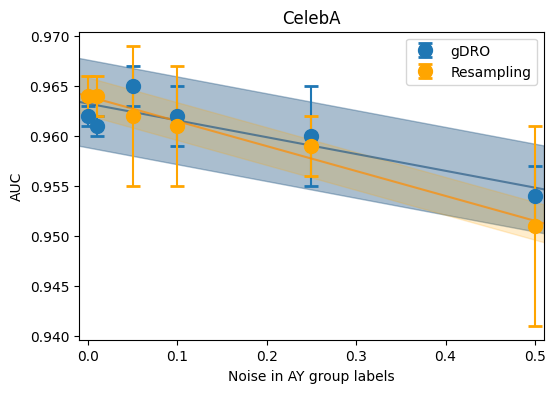

In [24]:
# gDRO
noise_overall_test_results = overall_results_df.loc[['AY','noisy_AY_001','noisy_AY_005','noisy_AY_010','noisy_AY_025','noisy_AY_050']]
noise_overall_std_test_results = overall_std_df.loc[['AY','noisy_AY_001','noisy_AY_005','noisy_AY_010','noisy_AY_025','noisy_AY_050']]

# rename index
noise_overall_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_std_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_test_results.index.name = 'Noise in AY groups'

x1 = noise_overall_test_results.index.values
y1 = noise_overall_test_results['AUC']
yerr1 = noise_overall_std_test_results['AUC']
plt.figure(figsize=(6, 4))
plt.errorbar(
    x1, y1, yerr=yerr1,
    fmt='o', markersize=10, capsize=5, capthick=2, label='gDRO'
)

slope1, intercept1, _, _, std_err1 = linregress(x1, y1)
line_x1 = np.linspace(min(x1)-0.01, max(x1)+0.01, 100)
line_y1 = slope1 * line_x1 + intercept1
stderr_fit1 = std_err1 * 1  # Adjusted CI margin
line_y_lower1 = line_y1 - stderr_fit1
line_y_upper1 = line_y1 + stderr_fit1

plt.plot(line_x1, line_y1, color='#2b5d87', alpha=0.7)
plt.fill_between(line_x1, line_y_lower1, line_y_upper1, alpha=0.4, color='#2b5d87')

# RESAMPLING
noise_overall_test_results = resampling_overall_results_df.loc[['AY','noisy_AY_001','noisy_AY_005','noisy_AY_010','noisy_AY_025','noisy_AY_050']]
noise_overall_std_test_results = resampling_overall_std_df.loc[['AY','noisy_AY_001','noisy_AY_005','noisy_AY_010','noisy_AY_025','noisy_AY_050']]

# rename index
noise_overall_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_std_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_test_results.index.name = 'Noise in AY groups'

x2 = noise_overall_test_results.index.values
y2 = noise_overall_test_results['AUC']
yerr2 = noise_overall_std_test_results['AUC']

plt.errorbar(
    x2, y2, yerr=yerr2,
    fmt='o', markersize=10, capsize=5, capthick=2, label='Resampling', color='orange'
)

slope2, intercept2, _, _, std_err2 = linregress(x2, y2)
line_x2 = np.linspace(min(x2)-0.01, max(x2)+0.01, 100)
line_y2 = slope2 * line_x2 + intercept2
stderr_fit2 = std_err2 * 1  # Adjusted CI margin
line_y_lower2 = line_y2 - stderr_fit2
line_y_upper2 = line_y2 + stderr_fit2

plt.plot(line_x2, line_y2, color='darkorange', alpha=0.7)
plt.fill_between(line_x2, line_y_lower2, line_y_upper2, alpha=0.2, color='orange')

plt.xlabel('Noise in AY group labels')
plt.ylabel('AUC')
plt.xlim(-0.01, 0.51)
# plt.ylim(0.8, 0.95)
plt.legend()
plt.title('CelebA')
plt.show()


In [25]:
plot_data = {
    "dataset": "CelebA",
    "methods": [
        {
            "label": "gDRO",
            "x": x1,
            "y": y1,
            "yerr": yerr1,
            "slope": slope1,
            "intercept": intercept1,
            "std_err": std_err1,
            "color": "#2b5d87"
        },
        {
            "label": "Resampling",
            "x": x2,
            "y": y2,
            "yerr": yerr2,
            "slope": slope2,
            "intercept": intercept2,
            "std_err": std_err2,
            "color": "orange"
        }
    ]
}

with open("processed_results/CelebA_noise_plot_data.pkl", "wb") as f:
    pickle.dump(plot_data, f)


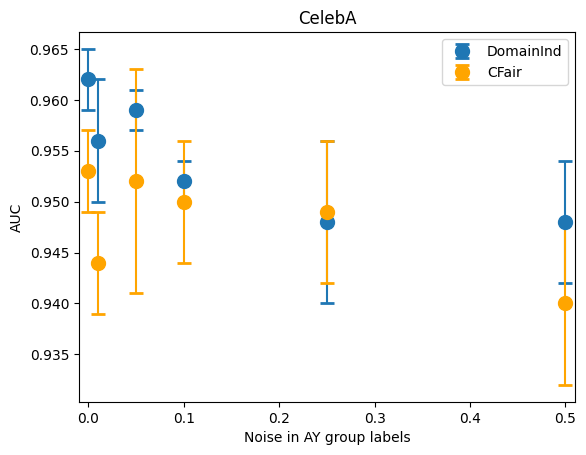

In [26]:
# DomainInd
noise_overall_test_results = DomainInd_overall_results_df.loc[['A','noisy_A_001','noisy_A_005','noisy_A_010','noisy_A_025','noisy_A_050']]
noise_overall_std_test_results = DomainInd_overall_std_df.loc[['A','noisy_A_001','noisy_A_005','noisy_A_010','noisy_A_025','noisy_A_050']]

# rename index
noise_overall_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_std_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_test_results.index.name = 'Noise in AY groups'

x1 = noise_overall_test_results.index.values
y1 = noise_overall_test_results['AUC']
yerr1 = noise_overall_std_test_results['AUC']

plt.errorbar(
    x1, y1, yerr=yerr1,
    fmt='o', markersize=10, capsize=5, capthick=2, label='DomainInd'
)

slope1, intercept1, _, _, std_err1 = linregress(x1, y1)
line_x1 = np.linspace(min(x1)-0.01, max(x1)+0.01, 100)
line_y1 = slope1 * line_x1 + intercept1
stderr_fit1 = std_err1 * 1  # Adjusted CI margin
line_y_lower1 = line_y1 - stderr_fit1
line_y_upper1 = line_y1 + stderr_fit1

# CFair
noise_overall_test_results = cfair_overall_results_df.loc[['A','noisy_A_001','noisy_A_005','noisy_A_010','noisy_A_025','noisy_A_050']]
noise_overall_std_test_results = cfair_overall_std_df.loc[['A','noisy_A_001','noisy_A_005','noisy_A_010','noisy_A_025','noisy_A_050']]

# rename index
noise_overall_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_std_test_results.index = [0,0.01,0.05,0.1,0.25,0.5]
noise_overall_test_results.index.name = 'Noise in AY groups'

x2 = noise_overall_test_results.index.values
y2 = noise_overall_test_results['AUC']
yerr2 = noise_overall_std_test_results['AUC']

plt.errorbar(
    x2, y2, yerr=yerr2,
    fmt='o', markersize=10, capsize=5, capthick=2, label='CFair', color='orange'
)

slope2, intercept2, _, _, std_err2 = linregress(x2, y2)
line_x2 = np.linspace(min(x2)-0.01, max(x2)+0.01, 100)
line_y2 = slope2 * line_x2 + intercept2
stderr_fit2 = std_err2 * 1  # Adjusted CI margin
line_y_lower2 = line_y2 - stderr_fit2
line_y_upper2 = line_y2 + stderr_fit2

# Customize the plot
plt.xlabel('Noise in AY group labels')
plt.ylabel('AUC')
plt.xlim(-0.01, 0.51)
plt.legend()
plt.title('CelebA')
plt.savefig('plots/celeba_domainind_cfair_noise_plot.pdf', bbox_inches='tight')

plt.show()


# Correlate performance with distance from P_test

In [48]:
p_test_distance_gdro_df = pd.read_csv('processed_results/kl_gdro.csv')
p_test_distance_gdro_df.set_index('Subgroup', inplace=True)

p_test_distance_resampling_df = pd.read_csv('processed_results/kl_resampling.csv')
p_test_distance_resampling_df.set_index('Subgroup', inplace=True)

resampling_results_p_test = pd.merge(resampling_overall_results_df,p_test_distance_resampling_df,left_index=True,right_index=True)
resampling_results_p_test['AUC std'] = resampling_overall_std_df['AUC']
resampling_results_p_test['Accuracy std'] = resampling_overall_std_df['Accuracy']

gdro_results_p_test = pd.merge(overall_results_df,p_test_distance_gdro_df,left_index=True,right_index=True)
gdro_results_p_test['AUC std'] = overall_std_df['AUC']
gdro_results_p_test['Accuracy std'] = overall_std_df['Accuracy']

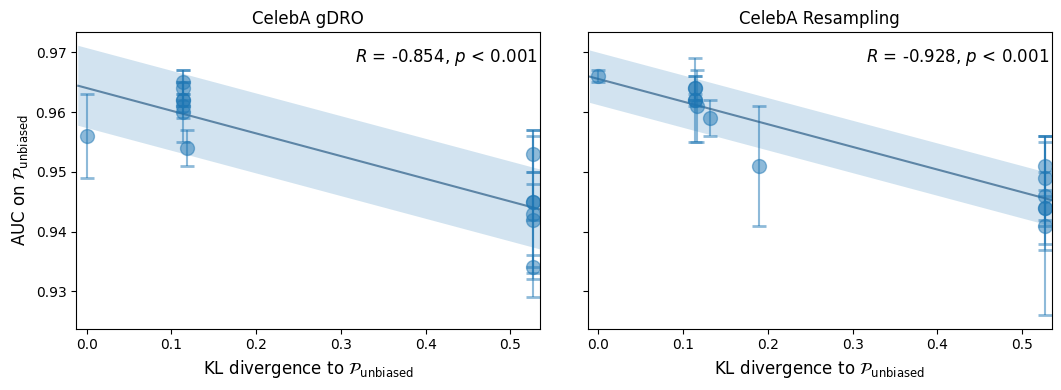

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].errorbar(
    gdro_results_p_test['KL_divergence'],
    gdro_results_p_test['AUC'],
    yerr=gdro_results_p_test['AUC std'],
    fmt='o',
    markersize=10,
    capsize=5,
    capthick=2,
    alpha=0.5
)
slope, intercept, r_value, p_value, std_err = linregress(gdro_results_p_test['KL_divergence'], gdro_results_p_test['AUC'])
line_x = np.linspace(min(gdro_results_p_test['KL_divergence'])-0.01, max(gdro_results_p_test['KL_divergence'])+0.01, 100)
line_y = slope * line_x + intercept
stderr_fit = gdro_results_p_test['AUC std'].std()  # Approximation for confidence interval width
line_y_lower = line_y - std_err
line_y_upper = line_y + std_err
axes[0].plot(line_x, line_y, label='Best fit line', color='#2b5d87', alpha=0.7)
axes[0].fill_between(line_x, line_y_lower, line_y_upper, alpha=0.2, label='95% CI')

# Compute and add Pearson correlation coefficient (ρ)
if p_value < 0.001:
    axes[0].text(0.6, 0.9, f"$R$ = {r_value:.3f}, $p$ < {0.001}", transform=axes[0].transAxes, fontsize=12) 
elif p_value < 0.01:
    axes[0].text(0.6, 0.9, f"$R$ = {r_value:.3f}, $p$ < {0.01}", transform=axes[0].transAxes, fontsize=12) 

axes[0].set_title("CelebA gDRO")
axes[0].set_xlabel(r"$\mathrm{KL}$ divergence to $\mathcal{P}_{\mathrm{unbiased}}$", fontsize=12)
axes[0].set_ylabel(r"AUC on $\mathcal{P}_{\mathrm{unbiased}}$", fontsize=12)
axes[0].set_xlim(-0.0125, 0.535)

axes[1].errorbar(
    resampling_results_p_test['KL_divergence'],
    resampling_results_p_test['AUC'],
    yerr=resampling_results_p_test['AUC std'],
    fmt='o',
    markersize=10,
    capsize=5,
    capthick=2,
    alpha=0.5
)
slope, intercept, r_value, p_value, std_err = linregress(resampling_results_p_test['KL_divergence'], resampling_results_p_test['AUC'])
line_x = np.linspace(min(resampling_results_p_test['KL_divergence'])-0.01, max(resampling_results_p_test['KL_divergence'])+0.01, 100)
line_y = slope * line_x + intercept
stderr_fit = resampling_results_p_test['AUC std'].std()  # Approximation for confidence interval width
line_y_lower = line_y - std_err
line_y_upper = line_y + std_err
axes[1].plot(line_x, line_y, label='Best fit line', color='#2b5d87', alpha=0.7)
axes[1].fill_between(line_x, line_y_lower, line_y_upper, alpha=0.2, label='95% CI')

# Compute and add Pearson correlation coefficient (ρ)
if p_value < 0.001:
    axes[1].text(0.6, 0.9, f"$R$ = {r_value:.3f}, $p$ < {0.001}", transform=axes[1].transAxes, fontsize=12) 

axes[1].set_title("CelebA Resampling")
axes[1].set_xlabel(r"$\mathrm{KL}$ divergence to $\mathcal{P}_{\mathrm{unbiased}}$", fontsize=12)
axes[1].set_xlim(-0.0125, 0.535)
plt.tight_layout()
plt.savefig("plots/Fig5_correlation_divergence_generalisation_gdro_resampling_celeba.pdf", format="pdf", bbox_inches="tight")
plt.show()
